# Recovery Strength Analysis

For each Gibbs component (EoR, Foregrounds, Systematics, Sky, Total Data) this notebook plots:
- **True** (Case I reference)
- **Mean** recovered field for Cases I, II, III
- **Residuals** (True − Mean) for each case

All panels are in delay–fringe-rate (DLFR) space.

In [1]:
import time
_notebook_start = time.time()

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1 import ImageGrid
from astropy import units as u
from tqdm import tqdm
import sys

from uvtools.utils import fourier_freqs
from plotting_functions import plot_waterfalls_from_dlfr
from plotting_codes.functions import data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes

## Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'
parent_dir = '/nvme2/scratch/sohini/hydra-pspec-systematic/'
fig_dir    = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'

# ── Test cases ────────────────────────────────────────────────────────────────
run_version_arr = ['low_dl_fr_0', 'high_dl_fr_0', 'low_dl_fr_20']

nm_list_arr = [
    [(3, 0),  (4, 0),  (5, 0),  (6, 0)],   # Case I
    [(10, 0), (11, 0), (12, 0), (13, 0)],  # Case II
    [(3, 20), (4, 20), (5, 20), (6, 20)],  # Case III
]

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80
Nfreqs   = 60
Nfgmodes = 10
Niter    = 100000

# ── True systematic amplitudes ────────────────────────────────────────────────
sys_amps_true = np.array([1. + 4j, 2 + 3j, 3. + 2j, 4. + 1j])

## Derived Parameters

In [3]:
freqs = np.load(parent_dir + 'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6   # MHz
lsts  = np.load(parent_dir + 'res/npy_data/lsts_full.npy')[:Ntimes]

df       = (freqs[1] - freqs[0]) * u.MHz
delays   = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))           # ns

lsts_sec  = lsts * 24. / (2. * np.pi) * 3600.                                 # LST → seconds
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_ones = dlfr(np.ones((Ntimes, Nfreqs), dtype='complex'))                   # DLFR(1)

## Styling

In [4]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 28})

# ── Diverging (teal ↔ berry) ──────────────────────────────────────────────────
paper_map = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.043, 0.329, 0.431)),
    (0.250, (0.306, 0.635, 0.710)),
    (0.500, (0.957, 0.953, 0.961)),
    (0.750, (0.816, 0.412, 0.494)),
    (1.000, (0.627, 0.118, 0.220))))

# ── Sequential (near-white → teal) ───────────────────────────────────────────
paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.953, 0.957, 0.965)),
    (0.500, (0.306, 0.635, 0.710)),
    (1.000, (0.043, 0.329, 0.431))))

colors   = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ff8fba']
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

## Data Loading — All Cases, All Components

For each case and each Gibbs component (EoR, FG, Sys, Sky, Data) we compute
the **online Welford mean** of the DLFR-transformed sample field.
This avoids storing large `[Niter, Ntimes, Nfreqs]` arrays.

> **Note on the True column:** EoR, FG and Sky truths are identical across cases
> (same signal injection). Systematics and Total Data truths are case-specific;
> Case I is used as the reference True panel for those components.

In [5]:
# ── Output containers ─────────────────────────────────────────────────────────
# True (case-specific for sys/data; reference = Case I for eor/fg/sky)
eor_true_ref  = None
fg_true_ref   = None
sky_true_ref  = None
sys_true_all  = [None] * 3
data_true_all = [None] * 3

# Sample means
mean_eor_all  = [None] * 3
mean_fg_all   = [None] * 3
mean_sys_all  = [None] * 3
mean_sky_all  = [None] * 3
mean_data_all = [None] * 3

# Residuals (True_i − Mean_i, using each case's own truth)
res_eor_all   = [None] * 3
res_fg_all    = [None] * 3
res_sys_all   = [None] * 3
res_sky_all   = [None] * 3
res_data_all  = [None] * 3

# ── Main loop ─────────────────────────────────────────────────────────────────
for case_i, run_ver in enumerate(run_version_arr):
    print(f'\n=== Case {case_i + 1} / 3  ({run_ver}) ===')
    op_i = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[case_i])

    # ── Load samples and true fields ──────────────────────────────────────────
    eor_true_i  = np.load(result_dir + run_ver + '/eor_true.npy')
    fg_true_i   = np.load(result_dir + run_ver + '/fg_true.npy')
    data_true_i = np.load(result_dir + run_ver + '/data_true.npy')
    fgmodes_i   = np.load(result_dir + run_ver + '/fgmodes.npy')
    fg_amps_i   = np.load(result_dir + run_ver + '/fg-amps.npy')
    eor_gcr_i   = np.load(result_dir + run_ver + '/gcr-eor.npy')
    b_sys_i     = np.load(result_dir + run_ver + '/b-sys.npy')

    delta_g_true_i = (op_i @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
    sky_true_i     = eor_true_i + fg_true_i

    # Set shared reference truths from Case I
    if case_i == 0:
        eor_true_ref = eor_true_i
        fg_true_ref  = fg_true_i
        sky_true_ref = sky_true_i

    sys_true_all[case_i]  = 1 + delta_g_true_i
    data_true_all[case_i] = data_true_i

    # ── Welford online mean for all 5 components ──────────────────────────────
    n_s     = 0
    eor_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    fg_mu   = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sys_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sky_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    data_mu = np.zeros((Ntimes, Nfreqs), dtype='complex')

    print('  Processing samples...')
    for j in tqdm(range(Niter)):
        fg_vis_j  = (fgmodes_i @ fg_amps_i[j].T).T
        dg_j      = (op_i @ b_sys_i[j]).reshape([Nfreqs, Ntimes]).T
        sky_j     = eor_gcr_i[j] + fg_vis_j
        data_j    = (1. + dg_j) * sky_j

        n_s += 1
        eor_mu  += (eor_gcr_i[j] - eor_mu) / n_s
        fg_mu   += (fg_vis_j     - fg_mu)  / n_s
        sys_mu  += (dg_j   - sys_mu) / n_s
        sky_mu  += (sky_j        - sky_mu) / n_s
        data_mu += (data_j       - data_mu)/ n_s

    mean_eor_all[case_i]  = eor_mu
    mean_fg_all[case_i]   = fg_mu
    mean_sys_all[case_i]  = sys_mu
    mean_sky_all[case_i]  = sky_mu
    mean_data_all[case_i] = data_mu

    res_eor_all[case_i]   = eor_true_i      - eor_mu
    res_fg_all[case_i]    = fg_true_i       - fg_mu
    res_sys_all[case_i]   = (1+delta_g_true_i)*(eor_true_i+fg_true_i) - (1+sys_mu)*(eor_true_i+fg_true_i)
    res_sky_all[case_i]   = sky_true_i      - sky_mu
    res_data_all[case_i]  = data_true_i     - data_mu

print('\nAll cases done.')


=== Case 1 / 3  (low_dl_fr_0) ===
3 0
4 0
5 0
6 0
  Processing samples...


100%|██████████| 100000/100000 [00:36<00:00, 2719.75it/s]



=== Case 2 / 3  (high_dl_fr_0) ===
10 0
11 0
12 0
13 0
  Processing samples...


100%|██████████| 100000/100000 [00:33<00:00, 2945.62it/s]



=== Case 3 / 3  (low_dl_fr_20) ===
3 20
4 20
5 20
6 20
  Processing samples...


100%|██████████| 100000/100000 [00:38<00:00, 2608.84it/s]


All cases done.


## Recovery Strength Figure

**Layout:** 5 rows × 7 columns.  
- Left block (cols 0–3): True + Mean I/II/III — log-scale pink colourmap, one shared colourbar.  
- Right block (cols 4–6): Residuals I/II/III — diverging colourmap, one shared colourbar.

Each row is an independent `ImageGrid` pair placed inside a `GridSpecFromSubplotSpec`.

In [6]:
import sys
sys.path.append('../hydra-pspec-systematic/')
import hydra_pspec as hp

noise_ps_val = 0.0004 #0.000004 #0.000004 # 0.0004 -- usual case
fourier_op = hp.utils.fourier_operator(Nfreqs, unitary=True)

noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = hp.pspec.covariance_from_pspec(noise_ps_true, fourier_op)
Ninv = np.diag(1./np.diag(N_true)) # get diagonal, invert, pack back into diagonal
n = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes) 
                    + 1.j*np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)
# Note factor of sqrt(2) above

Residual + shared noise figure saved.


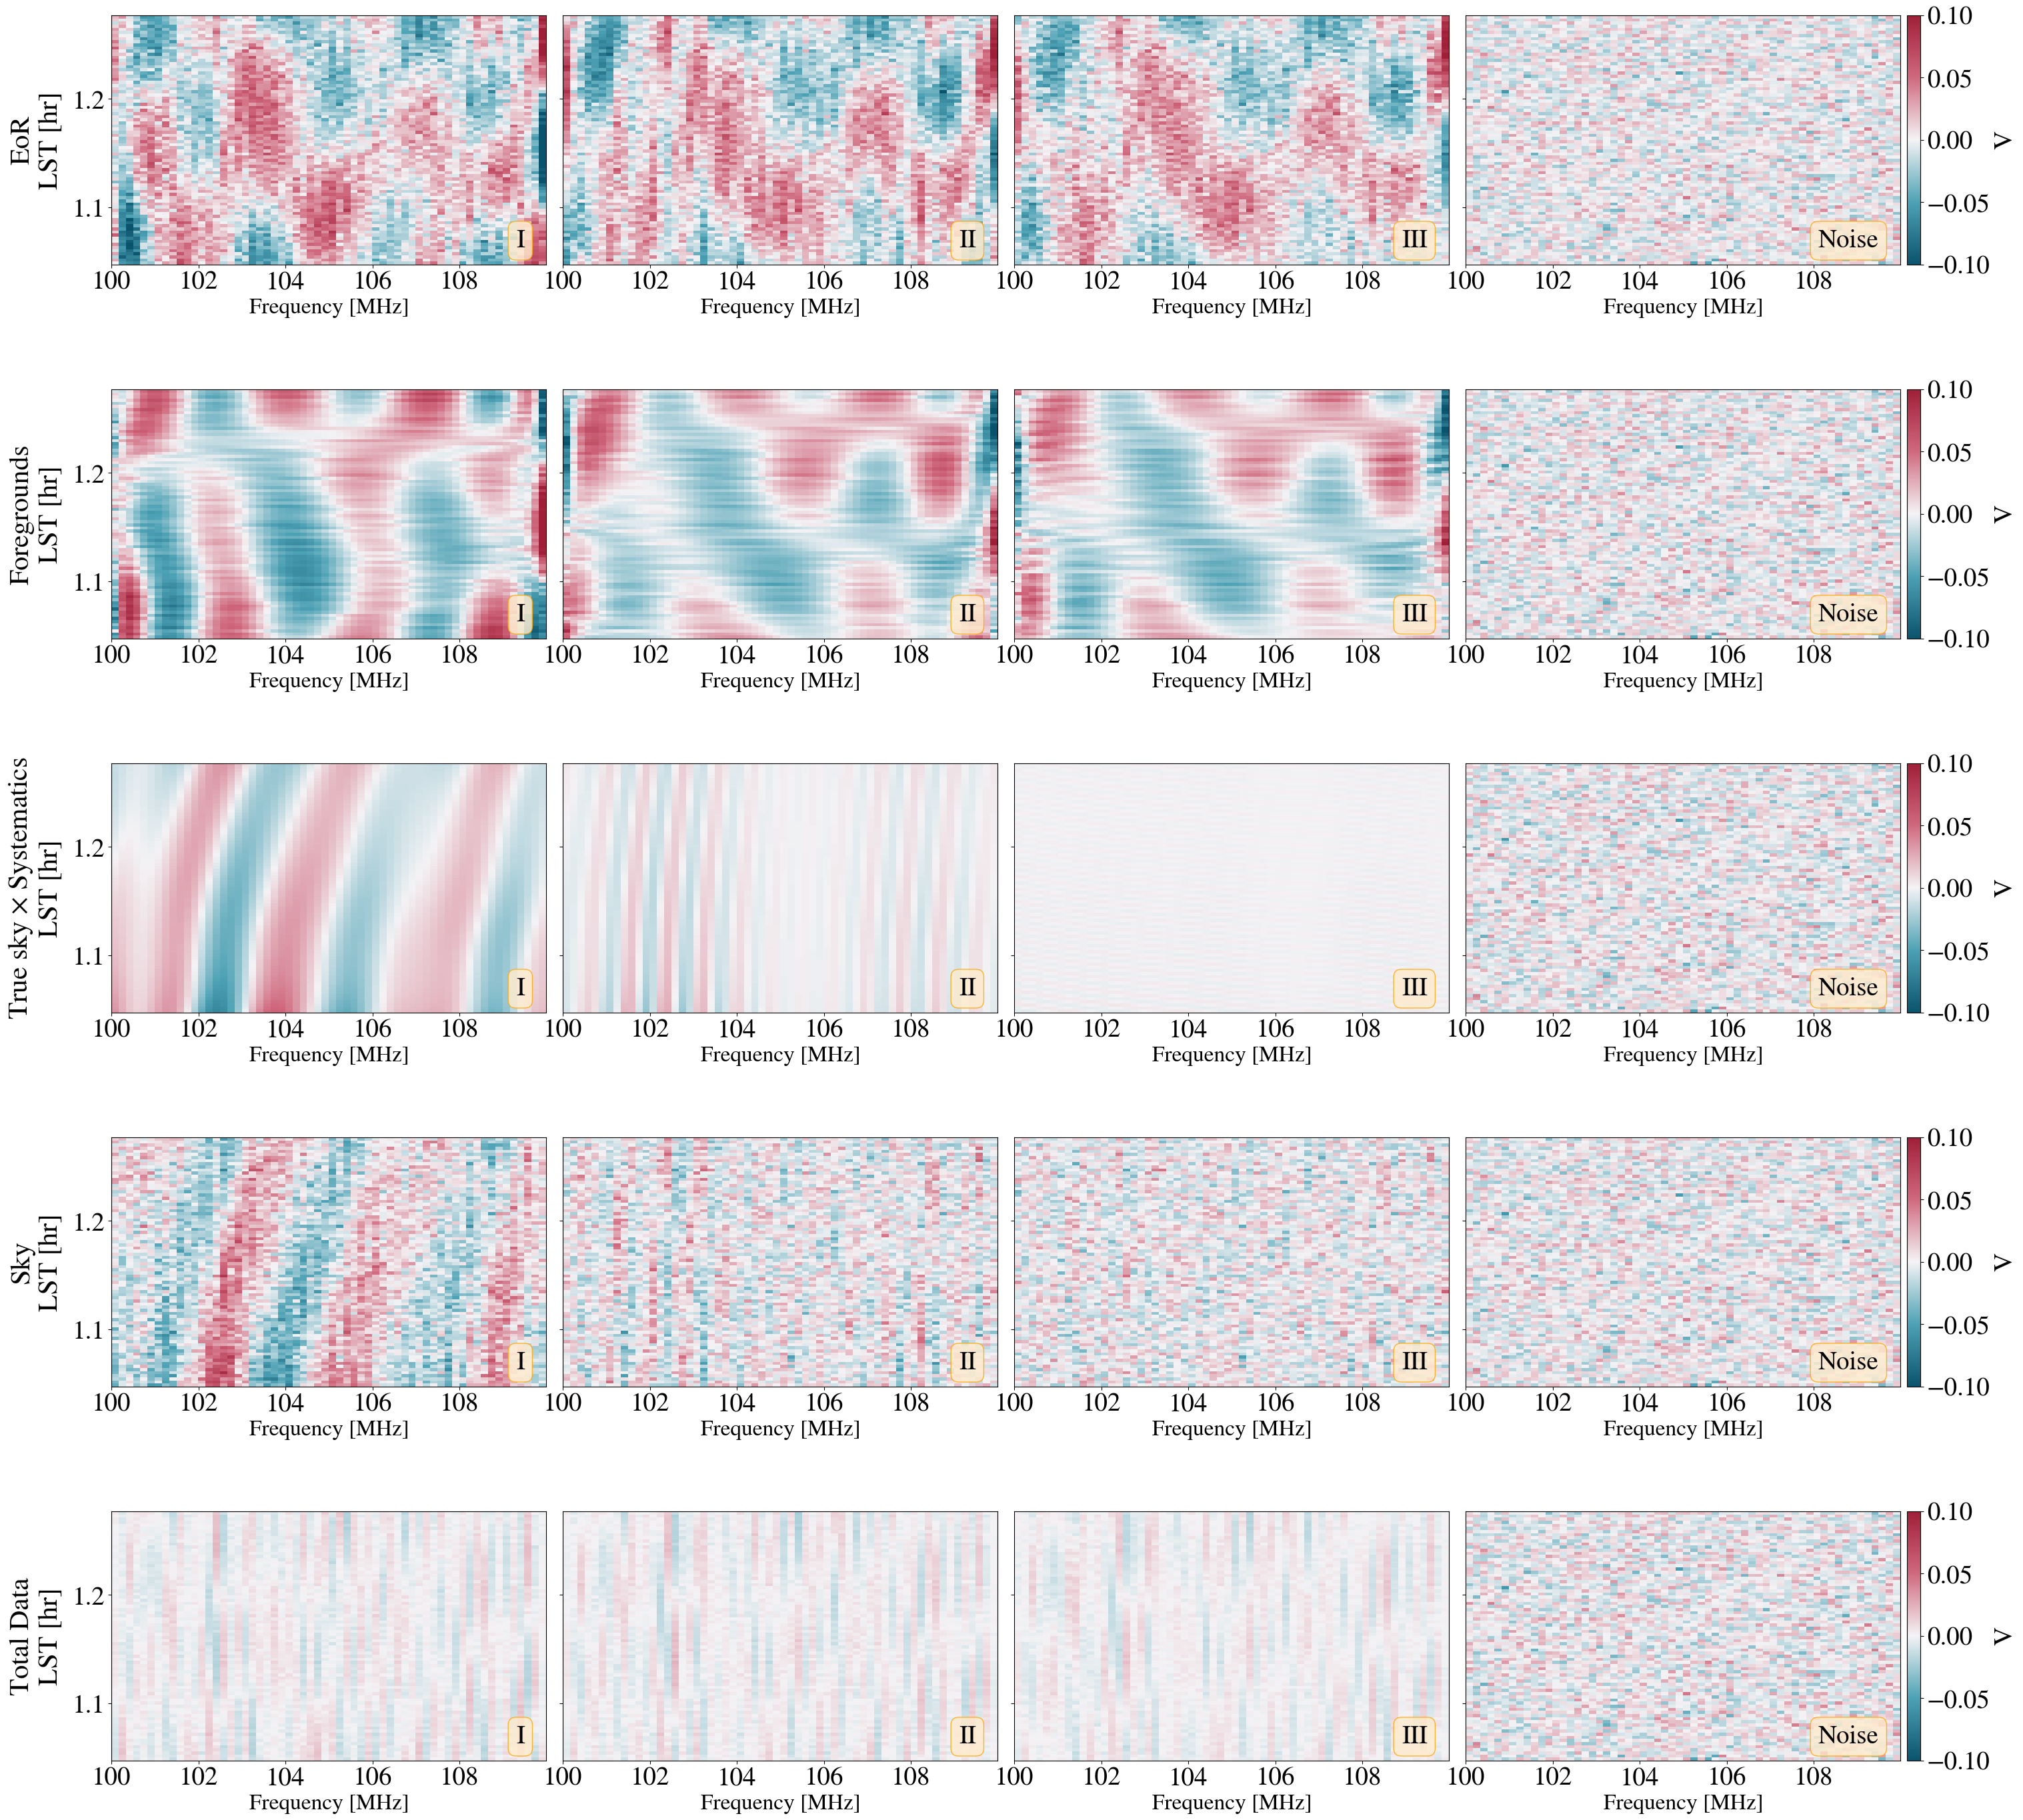

In [10]:
# ── Per-row plot configuration ────────────────────────────────────────────────
row_configs = [
    dict(
        label='EoR',
        true=eor_true_ref,
        means=mean_eor_all,
        res=res_eor_all,
    ),
    dict(
        label='Foregrounds',
        true=fg_true_ref,
        means=mean_fg_all,
        res=res_fg_all,
    ),
    dict(
        label=r'Systematics' + '\n' + r'($\delta g$)',
        true=sys_true_all,
        means=mean_sys_all,
        res=res_sys_all,
    ),
    dict(
        label='Sky',
        true=sky_true_ref,
        means=mean_sky_all,
        res=res_sky_all,
    ),
    dict(
        label='Total Data',
        true=data_true_all[0],
        means=mean_data_all,
        res=res_data_all,
    ),
]

case_lbl = ['I', 'II', 'III']
col_titles_main = ['True', r'$\mu$ Case I', r'$\mu$ Case II', r'$\mu$ Case III']
col_titles_res  = ['Res. Case I', 'Res. Case II', 'Res. Case III']

# ------------------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------------------

def prepare_for_imshow(arr, freqs, lsts, name='array'):
    """
    Ensure array shape matches (len(lsts), len(freqs)) for imshow with
    x = frequency and y = LST.
    """
    if arr is None:
        raise ValueError(f"{name} is None. It was never assigned before plotting.")

    arr = np.asarray(arr).squeeze()

    if arr.shape == (len(lsts), len(freqs)):
        return arr
    elif arr.shape == (len(freqs), len(lsts)):
        return arr.T
    else:
        raise ValueError(
            f"{name} has shape {arr.shape}, expected "
            f"{(len(lsts), len(freqs))} or {(len(freqs), len(lsts))}."
        )

def log_image(arr):
    """Plot log10(|arr|) safely without hard clipping."""
    return np.log10(np.clip(np.abs(arr), np.finfo(float).tiny, None))

extent = [freqs.min(), freqs.max(), lsts.min(), lsts.max()]

# ==============================================================================
# FIGURE 1: TRUE + MEANS
# ==============================================================================

# fig_main = plt.figure(figsize=(34, 35))
# outer_gs_main = GridSpec(5, 1, figure=fig_main, hspace=0.5)

# i=0
# for row, cfg in enumerate(row_configs):

#     grid_main = ImageGrid(
#         fig_main, outer_gs_main[row],
#         nrows_ncols=(1, 4),
#         axes_pad=0.25, share_all=True,
#         cbar_location='right', cbar_mode='single',
#         cbar_size='3%', cbar_pad=0.1, aspect=False,
#     )

#     # Prepare all panels first so row colour scale is data-driven
#     if i!=2:
#         true_img = prepare_for_imshow(cfg['true'], freqs, lsts, name=f"{cfg['label']} true")
#         true_plot = log_image(true_img)

#     mean_plots = []
#     for ci in range(3):
#         mean_img = prepare_for_imshow(
#             cfg['means'][ci], freqs, lsts,
#             name=f"{cfg['label']} mean case {ci+1}"
#         )
#         mean_plots.append(log_image(mean_img))

#     all_main = [true_plot] + mean_plots
#     main_vmin = min(np.nanmin(a) for a in all_main)
#     main_vmax = max(np.nanmax(a) for a in all_main)

#     # True
#     im_main = grid_main[0].imshow(
#         true_plot,
#         origin='lower',
#         aspect='auto',
#         extent=extent,
#         cmap=paper_map_blue,
#         vmin=main_vmin,
#         vmax=main_vmax,
#         interpolation='nearest',
#     )
#     grid_main[0].text(
#         0.95, 0.07, 'True', bbox=bbox,
#         transform=grid_main[0].transAxes, ha='right'
#     )

#     # Means
#     for ci in range(3):
#         im_main = grid_main[ci + 1].imshow(
#             mean_plots[ci],
#             origin='lower',
#             aspect='auto',
#             extent=extent,
#             cmap=paper_map_blue,
#             vmin=main_vmin,
#             vmax=main_vmax,
#             interpolation='nearest',
#         )
#         grid_main[ci + 1].text(
#             0.95, 0.07, r'$\mu$ ' + case_lbl[ci], bbox=bbox,
#             transform=grid_main[ci + 1].transAxes, ha='right'
#         )

#     # Shared colourbar
#     grid_main.cbar_axes[0].colorbar(im_main, label=r'$\log_{10}|V|$')

#     # Labels / limits
#     grid_main[0].set_ylabel(cfg['label'] + '\nLST [hr]', fontsize=30, labelpad=10)

#     for ax in grid_main:
#         ax.set_xlim(freqs.min(), freqs.max())
#         ax.set_ylim(lsts.min(), lsts.max())
#         ax.set_xlabel('Frequency [MHz]', fontsize=24)

#     # Column headers
#     if row == 0:
#         for ax, hdr in zip(grid_main, col_titles_main):
#             ax.set_title(hdr, fontsize=28, pad=12)

# ==============================================================================
# FIGURE 2: RESIDUALS + ONE SHARED NOISE COLUMN
# ==============================================================================
# noise_shared = np.load(parent_dir + 'res/npy_data/noise.npy')[:Ntimes, :Nfreqs]
noise_shared = n.T  # shape (Ntimes, Nfreqs) after transpose
row_configs_res = [
    dict(label=r'EoR',         res=res_eor_all),
    dict(label=r'Foregrounds', res=res_fg_all),
    dict(label=r'True sky $\times$ Systematics', res=res_sys_all),
    dict(label=r'Sky',         res=res_sky_all),
    dict(label=r'Total Data',  res=res_data_all),
]

col_titles_res = ['I', 'II', 'III', 'Noise']

fig_res = plt.figure(figsize=(35, 34))
outer_gs_res = GridSpec(len(row_configs_res), 1, figure=fig_res, hspace=0.5)

for row, cfg in enumerate(row_configs_res):

    grid_res = ImageGrid(
        fig_res, outer_gs_res[row],
        nrows_ncols=(1, 4),
        axes_pad=0.25, share_all=True,
        cbar_location='right', cbar_mode='single',
        cbar_size='3%', cbar_pad=0.1, aspect=False,
    )

    # --------------------------------------------------------------------------
    # Prepare row data: 3 residuals + 1 shared noise panel
    # --------------------------------------------------------------------------
    res_plots = []
    for ci in range(3):
        res_img = prepare_for_imshow(
            cfg['res'][ci], freqs, lsts,
            name=f"{cfg['label']} residual case {ci+1}"
        )
        res_plots.append(np.real(res_img))

    noise_plot = np.real(
        prepare_for_imshow(noise_shared, freqs, lsts, name='shared noise')
    )

    # Row-wise automatic symmetric scaling including the noise column
    all_row_arrays = res_plots + [noise_plot]
    row_absmax = max(np.nanmax(np.abs(a)) for a in all_row_arrays)

    if not np.isfinite(row_absmax) or row_absmax == 0:
        row_absmax = 1.0

    # --------------------------------------------------------------------------
    # Residual panels
    # --------------------------------------------------------------------------
    for ci in range(3):
        im_res = grid_res[ci].imshow(
            res_plots[ci],
            origin='lower',
            aspect='auto',
            extent=extent,
            cmap=paper_map,
            vmin=-0.1,
            vmax=0.1,
            interpolation='nearest',
        )
        grid_res[ci].text(
            0.95, 0.07, case_lbl[ci], bbox=bbox_res,
            transform=grid_res[ci].transAxes, ha='right'
        )

    # --------------------------------------------------------------------------
    # Shared noise column
    # --------------------------------------------------------------------------
    im_res = grid_res[3].imshow(
        noise_plot,
        origin='lower',
        aspect='auto',
        extent=extent,
        cmap=paper_map,
        vmin=-0.1,
        vmax=0.1,
        interpolation='nearest',
    )
    grid_res[3].text(
        0.95, 0.07, 'Noise', bbox=bbox_res,
        transform=grid_res[3].transAxes, ha='right'
    )

    # --------------------------------------------------------------------------
    # Shared colourbar for this row
    # --------------------------------------------------------------------------
    grid_res.cbar_axes[0].colorbar(im_res, label='V')

    # --------------------------------------------------------------------------
    # Labels / limits
    # --------------------------------------------------------------------------
    grid_res[0].set_ylabel(cfg['label'] + '\nLST [hr]', fontsize=30, labelpad=10)

    for ax in grid_res:
        ax.set_xlim(freqs.min(), freqs.max())
        ax.set_ylim(lsts.min(), lsts.max())
        ax.set_xlabel('Frequency [MHz]', fontsize=24)

    # --------------------------------------------------------------------------
    # Column headers on top row only
    # --------------------------------------------------------------------------
    # if row == 0:
    #     for ax, hdr in zip(grid_res, col_titles_res):
    #         ax.set_title(hdr, fontsize=28, pad=12)

# Optional save
fig_res.savefig(fig_dir + '/recovery_strength_residuals_with_noise.pdf',bbox_inches='tight', dpi=300)

print('Residual + shared noise figure saved.')

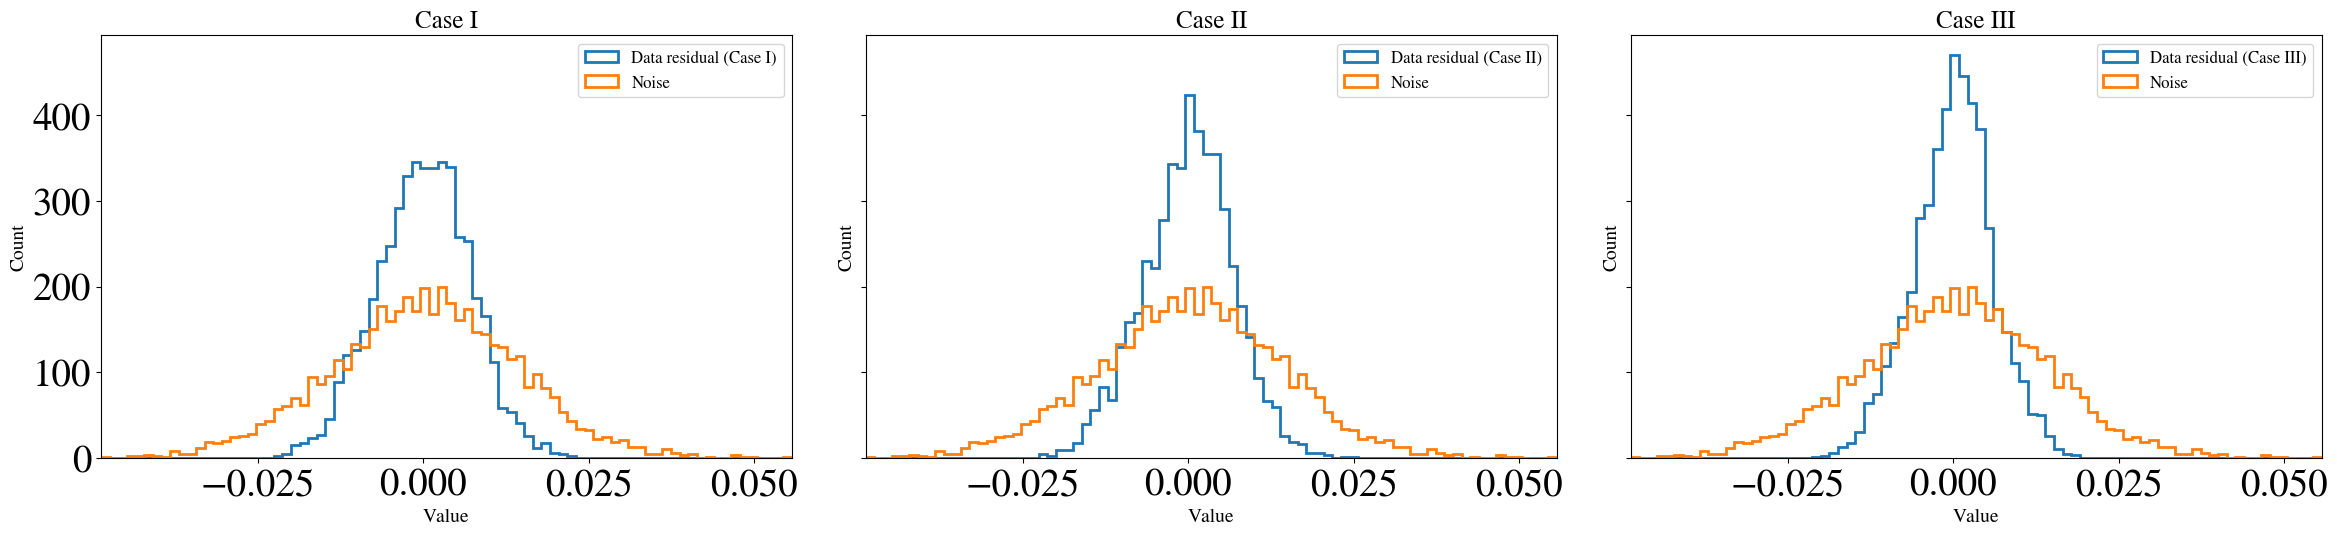

In [ ]:
# ==============================================================================
# HISTOGRAMS: DATA RESIDUAL vs NOISE
# ==============================================================================

# Choose what to compare: real part
data_residuals = [
    np.real(prepare_for_imshow(res_data_all[0], freqs, lsts, name='Data residual Case I')).ravel(),
    np.real(prepare_for_imshow(res_data_all[1], freqs, lsts, name='Data residual Case II')).ravel(),
    np.real(prepare_for_imshow(res_data_all[2], freqs, lsts, name='Data residual Case III')).ravel(),
]

noise_vals = np.real(
    prepare_for_imshow(noise_shared, freqs, lsts, name='Shared noise')
).ravel()

# --------------------------------------------------------------------------
# Build one common binning for everything
# --------------------------------------------------------------------------
all_vals = np.concatenate(data_residuals + [noise_vals])

xmin = np.nanmin(all_vals)
xmax = np.nanmax(all_vals)

nbins = 80
bins = np.linspace(xmin, xmax, nbins + 1)

# Common y-limit from all histograms
hist_max = 0
for arr in data_residuals + [noise_vals]:
    counts, _ = np.histogram(arr, bins=bins)
    hist_max = max(hist_max, np.max(counts))

# --------------------------------------------------------------------------
# Plot
# --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharex=True, sharey=True)

for ci, ax in enumerate(axes):
    ax.hist(
        data_residuals[ci],
        bins=bins,
        histtype='step',
        linewidth=2,
        label=f'Data residual ({case_lbl[ci]})',
    )
    ax.hist(
        noise_vals,
        bins=bins,
        histtype='step',
        linewidth=2,
        label='Noise',
    )

    ax.set_title(case_lbl[ci], fontsize=18)
    ax.set_xlabel('Value', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, 1.05 * hist_max)
    ax.legend(fontsize=12)

plt.tight_layout()
# plt.savefig(fig_dir + '/data_residual_vs_noise_histograms.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [10]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f'Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s')

Total notebook runtime: 00h 07m 45.8s
